100%|██████████| 26.4M/26.4M [00:01<00:00, 19.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 312kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.66MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.0MB/s]

Görüntü boyutu: torch.Size([1, 28, 28])
Etiket: 9


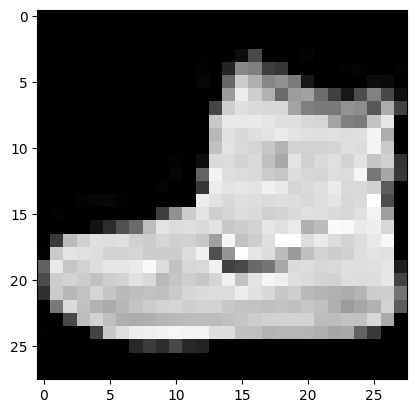

In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

image, label = train_dataset[0]
print(f"Görüntü boyutu: {image.shape}")
print(f"Etiket: {label}")

plt.imshow(image.squeeze(), cmap='gray')
plt.show()

In [4]:
cnn_model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

print(cnn_model)

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=400, out_features=64, bias=True)
  (8): ReLU()
  (9): Linear(in_features=64, out_features=10, bias=True)
)


In [5]:
loss_fn = nn.CrossEntropyLoss()
optimizerAda = torch.optim.m(cnn_model.parameters(), lr=0.001)

In [6]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [7]:
epochs = 3

for epoch in range(epochs):
    total_loss = 0
    for images, labels in train_loader:
        outputs = cnn_model(images)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Ortalama Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/3, Ortalama Loss: 0.6727
Epoch 2/3, Ortalama Loss: 0.4460
Epoch 3/3, Ortalama Loss: 0.3954


In [8]:
correct = 0
total = 0

cnn_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"Test Doğruluk Oranı: {accuracy:.2%}")

Test Doğruluk Oranı: 86.04%


## 👕 CNN Pekiştirme Projesi - Fashion-MNIST

**Veri seti:** Fashion-MNIST (10 kategori kıyafet sınıflandırma: tişört, pantolon, ayakkabı, çanta vb.)
**Amaç:** Bir önceki günde MNIST ile öğrenilen CNN mimarisini, farklı bir veri setinde tekrar kurarak pekiştirmek

**Model mimarisi:**
1 kanal (28x28) → Conv2d(8 filtre) → ReLU → MaxPool → Conv2d(16 filtre) → ReLU → MaxPool → Flatten → Linear(64) → ReLU → Linear(10 çıktı)

*(MNIST projesindeki mimarinin birebir aynısı — amaç, aynı yapıyı ikinci kez kurarak pekiştirmekti)*

**Pekiştirilen kavramlar:**
- Conv2d, ReLU, MaxPool2d katmanlarının anlamı ve parametreleri (in_channels, out_channels, kernel_size)
- Flatten ve boyut hesaplama (16×5×5=400 doğrulandı)
- DataLoader ile batch tabanlı eğitim
- Eğitim döngüsü: forward pass, loss hesaplama, backpropagation, optimizer.step()

**Sonuç:**
- 3 epoch eğitim sonunda loss değeri düzenli olarak azaldı
- **Test doğruluk oranı: %86.04**

**Çıkardığım ders:** Fashion-MNIST, MNIST'e göre daha zor bir problem (bazı kıyafet kategorileri birbirine görsel olarak çok benziyor), bu yüzden %86'lık sonuç bu problem için makul bir başarı. Aynı CNN mimarisini ikinci kez kurmak, ilk seferde net oturmayan kavramların (özellikle katman parametreleri ve boyut hesaplama) çok daha akıcı hale gelmesini sağladı — "yaparak öğrenmenin" gücünü somut olarak deneyimledim.